# SNLP Project: LLM Reasoning for Machine Translation
## MVA 2026 — Zebaze et al. (2025) Replication + Extensions

**Authors:** Tom Boumba, Allison Zhuang, Habibi Ahmed Salem, Ruben Cardoso

### Runtime guide:
- **Exp 1 (Thinking vs Non-Thinking):** ~45 min on T4 with Qwen3-0.6B
- **Exp 2 (ICL Few-shot):** ~30 min on T4
- **Exp 3 (CoT Prompting):** ~45 min on T4
- **Exp 4 (Fine-tuning):** ~3 hours on A100 (switch runtime!)

⚠️ **For Exp 4, go to Runtime > Change runtime type > A100**

In [ ]:
# ── CELL 1: INSTALL DEPENDENCIES ─────────────────────────────────────────
!pip install -q transformers accelerate datasets sacrebleu evaluate \
    sentencepiece protobuf bitsandbytes peft trl

import torch
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU — switch runtime!"}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB' if torch.cuda.is_available() else '')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 39.8 MB/s eta 0:00:00
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# ── CELL 2: GLOBAL CONFIG ────────────────────────────────────────────────
# Change these to control what runs

MODEL_NAME = 'Qwen/Qwen3-0.6B'   # Fits on T4 (15GB VRAM)
# MODEL_NAME = 'Qwen/Qwen3-1.7B' # Better quality, needs A100

LANG_PAIRS = [
    ('eng_Latn', 'fra_Latn', 'English', 'French'),   # High resource
    ('fra_Latn', 'eng_Latn', 'French', 'English'),   # Reverse
    ('eng_Latn', 'swh_Latn', 'English', 'Swahili'),  # Low resource
]

N_EVAL = 50   # Number of test sentences. Increase to 200 if time allows.

import json, re, random, pandas as pd, numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
import evaluate
from tqdm.notebook import tqdm

random.seed(42)
np.random.seed(42)

In [ ]:
# ── CELL 3: LOAD MODEL ───────────────────────────────────────────────────
import torch

print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto'
)
model.eval()
print('Model loaded!')

Loading Qwen/Qwen3-0.6B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded!


In [ ]:

# ── CELL 4: UTILITY FUNCTIONS (batched / parallelized generation) ─────────────

# Step 1: Login to HuggingFace (flores_plus is gated — run this once)
# Safer in Colab: store your token in a secret instead of hardcoding it.
from huggingface_hub import login
login()  # or: login(token=os.environ["HF_TOKEN"])

# Step 2: Fixed load_flores using the correct dataset path and API
def load_flores(src_lang, tgt_lang, split='devtest', n=50):
    src_ds = load_dataset('openlanguagedata/flores_plus', src_lang, split=split)
    tgt_ds = load_dataset('openlanguagedata/flores_plus', tgt_lang, split=split)
    return [ex['text'] for ex in src_ds][:n], [ex['text'] for ex in tgt_ds][:n]

# Quick test
test_src, test_ref = load_flores('eng_Latn', 'fra_Latn', split='devtest', n=3)
for s, r in zip(test_src, test_ref):
    print(f"EN: {s}\nFR: {r}\n")

# Generation helpers -------------------------------------------------------------
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Decoder-only LMs batch more efficiently with left padding.
tokenizer.padding_side = 'left'


def _extract_translation(decoded_text):
    """Strip thinking traces / prompt scaffolding and keep the final translation."""
    text = decoded_text.strip()

    if '</think>' in text:
        text = text.split('</think>')[-1].strip()

    markers = ['Final translation:', 'Translation:', '[Translation]:']
    lower_text = text.lower()
    for marker in markers:
        lower_marker = marker.lower()
        if lower_marker in lower_text:
            idx = lower_text.rfind(lower_marker)
            text = text[idx + len(marker):].strip()
            break

    return text.split('\n')[0].strip()


def _build_chat_prompts(sources, prompt_fn, enable_thinking=False):
    prompts = []
    for src in sources:
        msgs = [{'role': 'user', 'content': prompt_fn(src)}]
        prompts.append(
            tokenizer.apply_chat_template(
                msgs,
                tokenize=False,
                add_generation_prompt=True,
                enable_thinking=enable_thinking,
            )
        )
    return prompts


def translate(
    model,
    tokenizer,
    sources,
    prompt_fn,
    max_new_tokens=256,
    enable_thinking=False,
    batch_size=8,
):
    """
    Batched generation for much better GPU utilization on Colab.
    Falls back to a smaller batch automatically if CUDA OOM happens.
    """
    prompts = _build_chat_prompts(sources, prompt_fn, enable_thinking=enable_thinking)
    translations = []
    i = 0

    pbar = tqdm(total=len(prompts))
    while i < len(prompts):
        current_bs = min(batch_size, len(prompts) - i)

        while current_bs >= 1:
            batch_prompts = prompts[i:i + current_bs]
            try:
                inputs = tokenizer(
                    batch_prompts,
                    return_tensors='pt',
                    padding=True,
                    truncation=True,
                ).to(model.device)

                with torch.no_grad():
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        do_sample=False,
                        temperature=None,
                        top_p=None,
                        pad_token_id=tokenizer.pad_token_id,
                        eos_token_id=tokenizer.eos_token_id,
                        use_cache=True,
                    )

                input_lengths = inputs['attention_mask'].sum(dim=1).tolist()
                for row, prompt_len in zip(outputs, input_lengths):
                    generated_tokens = row[int(prompt_len):]
                    decoded = tokenizer.decode(generated_tokens, skip_special_tokens=True)
                    translations.append(_extract_translation(decoded))

                i += current_bs
                pbar.update(current_bs)
                break

            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()
                current_bs //= 2
                if current_bs == 0:
                    raise RuntimeError(
                        'Out of memory even with batch_size=1. '
                        'Lower max_new_tokens or use a smaller model.'
                    )

    pbar.close()
    return translations


def score(hyps, refs):
    bleu = evaluate.load('sacrebleu')
    chrf = evaluate.load('chrf')
    b = bleu.compute(predictions=hyps, references=[[r] for r in refs])['score']
    c = chrf.compute(predictions=hyps, references=[[r] for r in refs], word_order=2)['score']
    return round(b, 2), round(c, 2)

print('Utilities loaded! Batched translation is enabled.')


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

Generating dev split:   0%|          | 0/997 [00:00<?, ? examples/s]

...

fra_Latn.jsonl: 0.00B [00:00, ?B/s]

fra_Latn.jsonl: 0.00B [00:00, ?B/s]

Generating dev split:   0%|          | 0/997 [00:00<?, ? examples/s]

Generating devtest split:   0%|          | 0/1012 [00:00<?, ? examples/s]

EN: "We now have 4-month-old mice that are non-diabetic that used to be diabetic," he added.
FR: « Nous avons à présent des souris de 4 mois qui ne sont pas diabétiques alors qu'elles l'étaient auparavant », a-t-il ajouté.

EN: Dr. Ehud Ur, professor of medicine at Dalhousie University in Halifax, Nova Scotia and chair of the clinical and scientific division of the Canadian Diabetes Association cautioned that the research is still in its early days.
FR: Le Dr Ehud Ur, professeur de médecine à l'Université Dalhousie de Halifax (Nouvelle-Écosse) et président de la division clinique et scientifique de l'Association canadienne du diabète, a averti que la recherche en était encore à ses débuts.

EN: Like some other experts, he is skeptical about whether diabetes can be cured, noting that these findings have no relevance to people who already have Type 1 diabetes.
FR: À l'instar d'autres experts, il se montre sceptique quant à la possibilité de guérir le diabète, faisant remarquer que ces ré

## Experiment 1: Thinking vs Non-Thinking Mode

In [ ]:
# ── EXP 1: THINKING vs NON-THINKING ─────────────────────────────────────
exp1_results = []

for src_lang, tgt_lang, src_name, tgt_name in LANG_PAIRS:
    print(f'\n{src_name} → {tgt_name}')
    sources, references = load_flores(src_lang, tgt_lang, n=N_EVAL)

    for thinking, label in [(True, 'Thinking'), (False, 'Non-Thinking')]:
        fn = lambda s, sn=src_name, tn=tgt_name, t=thinking: (
            f'Please translate from {sn} to {tn}. Think step-by-step before giving the final translation.\n\nSentence: {s}'
            if t else
            f'Translate from {sn} to {tn}:\n{s}\nTranslation:'
        )
        hyps = translate(model, tokenizer, sources, fn,
                         max_new_tokens=512 if thinking else 128,
                         enable_thinking=thinking,
                         batch_size=1024)
        b, c = score(hyps, references)
        print(f'  {label:15s} → BLEU: {b:.2f} | chrF++: {c:.2f}')
        exp1_results.append({'src': src_name, 'tgt': tgt_name, 'mode': label,
                             'bleu': b, 'chrf': c, 'translations': hyps[:3]})

df1 = pd.DataFrame([{k:v for k,v in r.items() if k!='translations'} for r in exp1_results])
print('\n', df1.to_string(index=False))
with open('results_exp1.json', 'w') as f:
    json.dump(exp1_results, f, indent=2, ensure_ascii=False)


English → French


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

...

Generating devtest split:   0%|          | 0/1012 [00:00<?, ? examples/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  Thinking        → BLEU: 0.76 | chrF++: 8.54


  0%|          | 0/50 [00:00<?, ?it/s]

  Non-Thinking    → BLEU: 0.57 | chrF++: 7.55

     src     tgt         mode  bleu  chrf
English  French     Thinking 13.52 36.01
English  French Non-Thinking 24.93 50.49
 French English     Thinking 33.00 57.68
 French English Non-Thinking 30.61 59.12
English Swahili     Thinking  0.76  8.54
English Swahili Non-Thinking  0.57  7.55


## Experiment 2: ICL Few-Shot

In [ ]:
# ── EXP 2: ICL FEW-SHOT ──────────────────────────────────────────────────
exp2_results = []
N_SHOTS = [0, 1, 3, 5]

for src_lang, tgt_lang, src_name, tgt_name in LANG_PAIRS[:2]:  # Skip Swahili for speed
    demo_src, demo_tgt = load_flores(src_lang, tgt_lang, split='dev', n=100)
    test_src, test_ref = load_flores(src_lang, tgt_lang, split='devtest', n=N_EVAL)
    print(f'\n{src_name} → {tgt_name}')

    for k in N_SHOTS:
        def make_prompt(s, k=k):
            shots = random.sample(list(zip(demo_src, demo_tgt)), k) if k > 0 else []
            lines = [f'Translate from {src_name} to {tgt_name}:\n{ds}\nTranslation: {dt}\n'
                     for ds, dt in shots]
            lines.append(f'Translate from {src_name} to {tgt_name}:\n{s}\nTranslation:')
            return '\n'.join(lines)

        hyps = translate(model, tokenizer, test_src, make_prompt, max_new_tokens=150, batch_size=1024)
        b, c = score(hyps, test_ref)
        print(f'  {k}-shot → BLEU: {b:.2f} | chrF++: {c:.2f}')
        exp2_results.append({'src': src_name, 'tgt': tgt_name, 'k_shot': k, 'bleu': b, 'chrf': c})

df2 = pd.DataFrame(exp2_results)
print('\n', df2.to_string(index=False))
with open('results_exp2.json', 'w') as f:
    json.dump(exp2_results, f, indent=2)

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

...

  1-shot → BLEU: 31.90 | chrF++: 60.23


  0%|          | 0/50 [00:00<?, ?it/s]

  3-shot → BLEU: 30.47 | chrF++: 58.50


  0%|          | 0/50 [00:00<?, ?it/s]

  5-shot → BLEU: 30.68 | chrF++: 58.41

     src     tgt  k_shot  bleu  chrf
English  French       0 24.93 50.49
English  French       1 22.58 48.39
English  French       3 25.75 51.47
English  French       5 25.65 50.07
 French English       0 30.61 59.12
 French English       1 31.90 60.23
 French English       3 30.47 58.50
 French English       5 30.68 58.41


## Experiment 3: CoT Prompting Strategies

In [ ]:
# ── EXP 3: COT PROMPTING STRATEGIES ─────────────────────────────────────
exp3_results = []
N_COT = 30  # Keep low — these prompts are long

STRATEGIES = {
    'Baseline': lambda s, sn, tn: f'Translate from {sn} to {tn}:\n{s}\nTranslation:',
    'MAPS': lambda s, sn, tn: (
        f'Translate from {sn} to {tn} in 3 steps:\n'
        f'Step 1: Extract keywords and topics from: {s}\n'
        f'Step 2: Draft initial translation.\n'
        f'Step 3: Refine using keywords.\n'
        f'Final translation: '
    ),
    'TEaR': lambda s, sn, tn: (
        f'Translate, Evaluate, and Refine from {sn} to {tn}:\n'
        f'Source: {s}\n'
        f'Step 1 (Translate): Write initial translation.\n'
        f'Step 2 (Evaluate): Identify any issues.\n'
        f'Step 3 (Refine): Correct issues.\n'
        f'Final translation: '
    ),
    'Self-Refine': lambda s, sn, tn: (
        f'Translate from {sn} to {tn}:\n'
        f'Source: {s}\n'
        f'1. Write initial translation.\n'
        f'2. Critique it.\n'
        f'3. Write improved translation.\n'
        f'Final translation: '
    ),
}

for src_lang, tgt_lang, src_name, tgt_name in LANG_PAIRS[:2]:
    sources, references = load_flores(src_lang, tgt_lang, n=N_COT)
    print(f'\n{src_name} → {tgt_name}')

    for strat_name, strat_fn in STRATEGIES.items():
        fn = lambda s, sn=src_name, tn=tgt_name, sf=strat_fn: sf(s, sn, tn)
        hyps = translate(model, tokenizer, sources, fn, max_new_tokens=400, batch_size=1024)
        b, c = score(hyps, references)
        print(f'  {strat_name:15s} → BLEU: {b:.2f} | chrF++: {c:.2f}')
        exp3_results.append({'src': src_name, 'tgt': tgt_name,
                             'strategy': strat_name, 'bleu': b, 'chrf': c,
                             'samples': list(zip(sources[:3], hyps[:3], references[:3]))})

df3 = pd.DataFrame([{k:v for k,v in r.items() if k!='samples'} for r in exp3_results])
print('\n', df3.to_string(index=False))
with open('results_exp3.json', 'w') as f:
    json.dump(exp3_results, f, indent=2, ensure_ascii=False)

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]


English → French


...

  MAPS            → BLEU: 29.83 | chrF++: 53.19


  0%|          | 0/30 [00:00<?, ?it/s]

  TEaR            → BLEU: 0.97 | chrF++: 5.05


  0%|          | 0/30 [00:00<?, ?it/s]

  Self-Refine     → BLEU: 28.18 | chrF++: 56.70

     src     tgt    strategy  bleu  chrf
English  French    Baseline 25.43 51.13
English  French        MAPS 13.22 36.20
English  French        TEaR  2.49 14.23
English  French Self-Refine  0.88  8.35
 French English    Baseline 31.56 60.06
 French English        MAPS 29.83 53.19
 French English        TEaR  0.97  5.05
 French English Self-Refine 28.18 56.70


## Experiment 4: Fine-Tuning (IoFT + CoTFT)
⚠️ **Switch to A100 runtime before running this cell!**
Runtime > Change runtime type > A100

In [ ]:
# ── EXP 4: FINE-TUNING ───────────────────────────────────────────────────
# Only run on A100!
!pip install -q peft trl

from peft import LoraConfig, get_peft_model, TaskType
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq
from datasets import Dataset

FT_MODEL = 'Qwen/Qwen3-0.6B'
FT_SRC_LANG, FT_TGT_LANG = 'eng_Latn', 'fra_Latn'
FT_SRC_NAME, FT_TGT_NAME = 'English', 'French'
N_TRAIN = 500    # Paper uses 5000+; 500 is enough to show trends
MAX_STEPS = 300  # ~1.5h on A100 for 0.6B model

def load_data(n_train=500, n_eval=50):
    tr_src, tr_tgt = [], []
    src_ds = load_dataset('openlanguagedata/flores_plus', FT_SRC_LANG, split='dev', trust_remote_code=True)
    tgt_ds = load_dataset('openlanguagedata/flores_plus', FT_TGT_LANG, split='dev', trust_remote_code=True)
    tr_src = [ex['text'] for ex in src_ds][:n_train]
    tr_tgt = [ex['text'] for ex in tgt_ds][:n_train]
    src_ds2 = load_dataset('openlanguagedata/flores_plus', FT_SRC_LANG, split='devtest', trust_remote_code=True)
    tgt_ds2 = load_dataset('openlanguagedata/flores_plus', FT_TGT_LANG, split='devtest', trust_remote_code=True)
    ev_src = [ex['text'] for ex in src_ds2][:n_eval]
    ev_tgt = [ex['text'] for ex in tgt_ds2][:n_eval]
    return tr_src, tr_tgt, ev_src, ev_tgt

tr_src, tr_tgt, ev_src, ev_tgt = load_data()

def make_ioft_example(s, t, tok):
    text = f'Translate from English to French:\n{s}\nTranslation: {t}{tok.eos_token}'
    enc = tok(text, truncation=True, max_length=256)
    enc['labels'] = enc['input_ids'].copy()
    return enc

def make_cotft_example(s, t, tok):
    trace = (f'Keywords: [analyzing...]\nInitial draft: {t}\nRefined: {t}')
    text = f'Translate from English to French:\n{s}\n<think>\n{trace}\n</think>\nTranslation: {t}{tok.eos_token}'
    enc = tok(text, truncation=True, max_length=512)
    enc['labels'] = enc['input_ids'].copy()
    return enc

def train_model(train_examples, out_dir, steps=300):
    tok = AutoTokenizer.from_pretrained(FT_MODEL)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = 'left'

    m = AutoModelForCausalLM.from_pretrained(FT_MODEL, torch_dtype=torch.float16)
    m = m.to('cuda')
    lora = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=16,
        lora_alpha=32,
        target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
        lora_dropout=0.05,
    )
    m = get_peft_model(m, lora)
    m.print_trainable_parameters()

    ds = Dataset.from_list(train_examples)
    args = TrainingArguments(
        output_dir=out_dir,
        max_steps=steps,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=1e-4,
        warmup_steps=30,
        fp16=True,
        logging_steps=25,
        save_steps=150,
        report_to='none',
        remove_unused_columns=False,
    )
    trainer = Trainer(
        model=m,
        args=args,
        train_dataset=ds,
        data_collator=DataCollatorForSeq2Seq(tok, model=m, padding=True),
    )
    trainer.train()
    return m, tok

def eval_ft_model(m, tok, sources, refs, batch_size=8, max_new_tokens=150):
    m.eval()

    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = 'left'

    prompts = [f'Translate from English to French:\n{s}\nTranslation:' for s in sources]
    hyps = []
    i = 0

    pbar = tqdm(total=len(prompts), desc='Evaluating FT model')
    while i < len(prompts):
        current_bs = min(batch_size, len(prompts) - i)

        while current_bs >= 1:
            batch_prompts = prompts[i:i + current_bs]
            try:
                inputs = tok(
                    batch_prompts,
                    return_tensors='pt',
                    padding=True,
                    truncation=True,
                ).to(m.device)

                with torch.no_grad():
                    outputs = m.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        do_sample=False,
                        temperature=None,
                        top_p=None,
                        pad_token_id=tok.pad_token_id,
                        eos_token_id=tok.eos_token_id,
                        use_cache=True,
                    )

                input_lengths = inputs['attention_mask'].sum(dim=1).tolist()
                for row, prompt_len in zip(outputs, input_lengths):
                    decoded = tok.decode(row[int(prompt_len):], skip_special_tokens=True)
                    hyps.append(decoded.split('\n')[0].strip())

                i += current_bs
                pbar.update(current_bs)
                break

            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()
                current_bs //= 2
                if current_bs == 0:
                    raise RuntimeError(
                        'Out of memory during FT evaluation even with batch_size=1. '
                        'Lower max_new_tokens or use a smaller batch.'
                    )

    pbar.close()
    return score(hyps, refs)

# Train IoFT
print('Training IoFT...')
ioft_tok = AutoTokenizer.from_pretrained(FT_MODEL)
if ioft_tok.pad_token is None:
    ioft_tok.pad_token = ioft_tok.eos_token
ioft_tok.padding_side = 'left'

ioft_examples = [make_ioft_example(s, t, ioft_tok) for s, t in zip(tr_src, tr_tgt)]
ioft_model, ioft_tok = train_model(ioft_examples, './ioft_ckpt')
b_ioft, c_ioft = eval_ft_model(ioft_model, ioft_tok, ev_src, ev_tgt)
print(f'IoFT → BLEU: {b_ioft:.2f} | chrF++: {c_ioft:.2f}')

import gc
del ioft_model
gc.collect()
torch.cuda.empty_cache()

# Train CoTFT
print('\nTraining CoTFT(MAPS)...')
cotft_tok = AutoTokenizer.from_pretrained(FT_MODEL)
if cotft_tok.pad_token is None:
    cotft_tok.pad_token = cotft_tok.eos_token
cotft_tok.padding_side = 'left'

cotft_examples = [make_cotft_example(s, t, cotft_tok) for s, t in zip(tr_src, tr_tgt)]
cotft_model, cotft_tok = train_model(cotft_examples, './cotft_ckpt')
b_cotft, c_cotft = eval_ft_model(cotft_model, cotft_tok, ev_src, ev_tgt)
print(f'CoTFT(MAPS) → BLEU: {b_cotft:.2f} | chrF++: {c_cotft:.2f}')

exp4_results = [
    {'condition': 'IoFT', 'bleu': b_ioft, 'chrf': c_ioft},
    {'condition': 'CoTFT(MAPS)', 'bleu': b_cotft, 'chrf': c_cotft},
]
print('\nFINE-TUNING SUMMARY:')
print(pd.DataFrame(exp4_results).to_string(index=False))
with open('results_exp4.json', 'w') as f:
    json.dump(exp4_results, f, indent=2)


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlanguagedata/flores_plus' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlanguagedata/flores_plus' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlanguagedata/flores_plus' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlanguagedata/flores_plus' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

...

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 4,587,520 || all params: 756,219,904 || trainable%: 0.6066


Step,Training Loss
25,1.570188
50,1.026865
75,0.895309
100,0.857318
125,0.834267
150,0.819405
175,0.797078
200,0.797900
225,0.778911
250,0.767986


Evaluating FT model:   0%|          | 0/50 [00:00<?, ?it/s]

CoTFT(MAPS) → BLEU: 4.07 | chrF++: 20.41

FINE-TUNING SUMMARY:
  condition  bleu  chrf
       IoFT  3.63 19.82
CoTFT(MAPS)  4.07 20.41


## Final: Aggregate Results Table

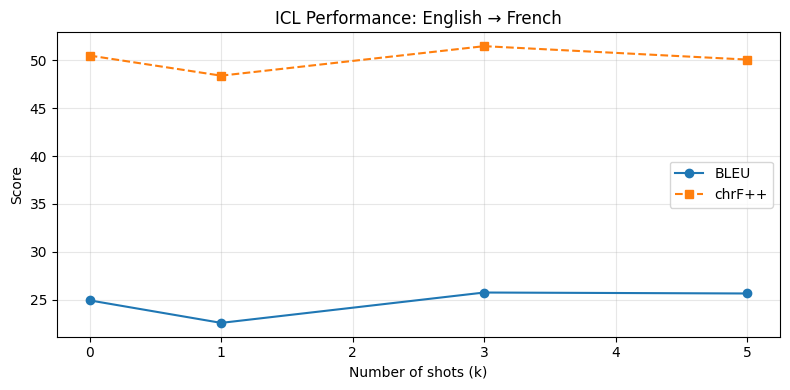

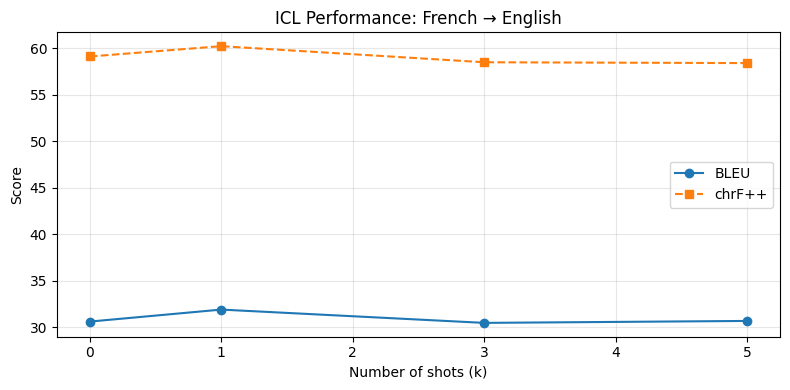


All experiments complete!


In [ ]:
# ── FINAL RESULTS AGGREGATION ────────────────────────────────────────────
import matplotlib.pyplot as plt

# Load all results
all_data = []
for fname, exp in [('results_exp1.json','thinking'), ('results_exp2.json','icl'),
                   ('results_exp3.json','cot'), ('results_exp4.json','finetune')]:
    try:
        with open(fname) as f:
            data = json.load(f)
        for d in data:
            d['experiment'] = exp
        all_data.extend(data)
    except FileNotFoundError:
        print(f'Missing: {fname}')

# Plot Experiment 2: ICL
try:
    with open('results_exp2.json') as f:
        icl_data = json.load(f)
    df_icl = pd.DataFrame(icl_data)
    for lang_pair in df_icl[['src','tgt']].drop_duplicates().itertuples():
        sub = df_icl[(df_icl.src==lang_pair.src) & (df_icl.tgt==lang_pair.tgt)]
        plt.figure(figsize=(8,4))
        plt.plot(sub.k_shot, sub.bleu, 'o-', label='BLEU')
        plt.plot(sub.k_shot, sub.chrf, 's--', label='chrF++')
        plt.xlabel('Number of shots (k)')
        plt.ylabel('Score')
        plt.title(f'ICL Performance: {lang_pair.src} → {lang_pair.tgt}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'icl_plot_{lang_pair.src}_{lang_pair.tgt}.png', dpi=150)
        plt.show()
except Exception as e:
    print(f'Could not plot ICL: {e}')

print('\nAll experiments complete!')